Прежде, чем приступать к этому ноутбуку вспомните/изучите, что такое **сверточные нейронные сети**.  
Вы можете это сделать каким угодно способом, но для выполнения заданий нельзя использовать БЯМ.  
[Вот тут хабр на русском](https://habr.com/ru/companies/skillfactory/articles/565232/),
[Вот тут очень хорошо, но на английском](https://learnopencv.com/understanding-convolutional-neural-networks-cnn/).

> Напоминаю, что в этом задании **НЕЛЬЗЯ ИСПОЛЬЗОВАТЬ БЯМ**! Вы точно сможете справиться с ним самостоятельно при использовании обычного поиска, статей и документации!
***

В этом задании вы познакомитесь с основными архитектурами сверточных нейронных сетей (CNN) на примере задачи классификации изображений. Мы будем работать с датасетом **Tiny ImageNet** — уменьшенной версией популярного датасета [**ImageNet**](https://www.image-net.org/about.php).

Цели этого задания:

* Изучить процесс подготовки данных для обучения сверточных нейросетей
* Реализовать и обучить две классические архитектуры CNN: **VGG-like** и **ResNet-like**
* Понять преимущества остаточных соединений
* Научиться анализировать результаты обучения

_После выполнения задания проверьте себя, что вы поняли хотя бы что-то по каждому из пунктов!_
***

**Что такое сверточные нейронные сети?**
Сверточные сети (CNN) — это тип нейронных сетей для обработки данных с топологической структурой (изображения, видео), основанный на математической операции свертки. Основные компоненты таких сетей (в базовом применении):

- **Сверточные слои** — выделяют локальные признаки (края, текстуры)
- **Пулинг** — уменьшает пространственное разрешение, повышая инвариантность
- **Полносвязные слои** — классифицируют признаки
- Иногда еще могут добавлять нормализацию **BatchNorm**

Полезно посмотреть документацию: [Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html),
[MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html),
[BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html).

# Часть 0: данные

In [1]:
!nvidia-smi

Thu Mar  5 17:23:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Tiny ImageNet содержит:

* 100k изображений размером 64×64×3
* 200 классов объектов (животные, транспорт, предметы)
* Фактически, это подмножество набора данных ImageNet с изображениями, уменьшенными в 4 раза.

![изображение.png](attachment:268b3a77-e945-4215-86cf-1bb05bf29103.png)

**Важно**: для загрузки и корректной обработки вам понадобятся скрипты `tiny_img.py` и `tiny_img_dataset.py`.

In [4]:
import torch
import torchvision
from torchvision import transforms
from tqdm.auto import tqdm
from torch.utils.data import Dataset
import os
from PIL import Image


def get_computing_device():
    if torch.cuda.is_available():
        device = torch.device('cuda:0')
    else:
        device = torch.device('cpu')
    return device

device = get_computing_device()
print(f"Our main computing device is '{device}'")
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

Our main computing device is 'cuda:0'
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [5]:
# Вы можете это не запускать и скачать архив с диска
from tiny_img import download_tinyImg200
data_path = '.'
download_tinyImg200(data_path)

Dataset was downloaded to './tiny-imagenet-200.zip'
Extract downloaded dataset to '.'


Теперь перейдем к загрузке датасета непосредственно в наш ноутбук.

Обычно для **манипулирования данными** используются две связанные сущности:

* Dataset (`torch.utils.data.Dataset` и его подклассы из `torchvision.datasets`) - некоторый черный ящик, который хранит и предварительно обрабатывает отдельные элементы набора данных. В частности, на этом уровне обычно находятся [аугментации](https://habr.com/ru/companies/magnus-tech/articles/850070/) для отдельных сэмплов.
* DataLoader (`torch.utils.data.DataLoader`) - структура, которая объединяет отдельные элементы в батчи (набор сэмплов).

Давайте разберемся с обучающим набором данных. Вот несколько простых [аугментаций](https://docs.pytorch.org/vision/0.9/transforms.html), которые можно использовать:
- `transforms.RandomHorizontalFlip()`,
- `transforms.ToTensor()`,
- `transforms.RandomRotation(5)`,
- `torchvision.transforms.ColorJitter(brightness=..., contrast=..., saturation=..., hue=...)`.

In [6]:
# TODO: Дополните список аугментаций
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    # добавьте ColorJitter с умеренными параметрами
    transforms.ColorJitter(brightness = 0.3, contrast = 0.1, hue = 0.3, saturation = 0.05),
    # можете добавить еще те аугментации, которые считаете нужными
    transforms.ToTensor()
])

Для обучающего датасета мы будем использовать кастомный Dataset, который будет хранить все обучающие данные в оперативной памяти. Если у вас недостаточно оперативной памяти, вы можете использовать `torchvision.datasets.ImageFolder()`.

In [7]:
import tiny_img_dataset
train_dataset = tiny_img_dataset.TinyImagenetRAM('tiny-imagenet-200/train', transform=train_transforms)

tiny-imagenet-200/train: 100%|██████████| 200/200 [01:12<00:00,  2.77it/s]


Теперь проверка. Взгляните на папку _tiny-imagenet-200/val_ и сравните ее с папкой _tiny-imagenet-200/train_. Выглядит по-другому, не так ли? Таким образом, мы не можем использовать `TinyImagenetRAM` для загрузки валидационной выборки. Давайте вместо этого напишем свой `Dataset`, но с таким же поведением, как у `TinyImagenetRAM`. [Вот тут можно почитать](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html) про то, как это делать и чем что от чего отличается.

In [8]:
class TinyImagenetValDataset(Dataset):
    def __init__(self, root, transform=transforms.ToTensor()):
        super().__init__()

        self.root = root
        with open(os.path.join(root, 'val_annotations.txt')) as f:
            annotations = []
            for line in f:
                img_name, class_label = line.split('\t')[:2]
                annotations.append((img_name, class_label))

        # TODO: определите self.classes - список отсортированных меток классов из аннотаций
        # это должно выглядеть как self.classes из "TinyImagenetRAM"
        self.classes = sorted(set([class_label for img_name, class_label in annotations]))

        assert len(self.classes) == 200, len(self.classes)
        assert all(self.classes[i] < self.classes[i+1] for i in range(len(self.classes)-1)), 'classes should be ordered'
        assert all(isinstance(elem, type(annotations[0][1])) for elem in self.classes), 'your just need to reuse class_labels'

        # TODO: self.class_to_idx - словать от метки класса к индексу класса
        self.class_to_idx = {class_label: index for index, class_label in enumerate(self.classes)}

        self.transform = transform

        self.images, self.targets = [], []
        for img_name, class_name in tqdm(annotations, desc=root):
            img_name = os.path.join(root, 'images', img_name)
            # TODO: загрузите изображение и сохраните его в self.images
            image = tiny_img_dataset.read_rgb_image(img_name)

            assert image.shape == (64, 64, 3), image.shape
            self.images.append(Image.fromarray(image))
            # сохраните индекс класса в self.targets
            self.targets.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        # TODO: возьмите изображение и его целевую метку из "self.images" и "self.targets",
        # преобразуйте изображение с помощью self.transform и верните преобразованное изображение и его целевую метку
        image = self.transform(self.images[index])
        target = self.targets[index]
        return image, target

Давайте, наконец, загрузим валидационную выборку. Обычно вам не нужно аугментировать данные для валидации.

In [9]:
val_dataset = TinyImagenetValDataset('tiny-imagenet-200/val', transform=transforms.ToTensor())

assert all(train_dataset.classes[i] == val_dataset.classes[i] for i in range(200)), \
    'class order in train and val datasets should be the same'
assert all(train_dataset.class_to_idx[elem] == val_dataset.class_to_idx[elem] for elem in train_dataset.classes), \
    'class indices should be the same'

tiny-imagenet-200/val:   0%|          | 0/10000 [00:00<?, ?it/s]

В большинстве случаев будет достаточно стандартного даталоадера.

In [10]:
batch_size = 64
# меняйте num_workers в зависимости от вашего железа
train_batch_gen = torch.utils.data.DataLoader(train_dataset,
                                              batch_size=batch_size,
                                              shuffle=True,
                                              num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [11]:
val_batch_gen = torch.utils.data.DataLoader(val_dataset,
                                            batch_size=batch_size,
                                            shuffle=False,
                                            num_workers=4)

# Часть 1: VGG

Начнем наши реалицации с освоения архитектуры **VGG**.  
[Про то, что это за архитектура](https://www.geeksforgeeks.org/computer-vision/vgg-net-architecture-explained/), [оригинатьная статья](https://disk.yandex.ru/i/tgsx7mz5IvrrNA).

**"VGG-like"**, обычно означает, что сеть представляет собой последовательность **сверток** с **MaxPooling** для уменьшения дискретизации. В оригинальной статье есть таблица, в которой описываются классические конфигурации сетей VGG (часто называемые VGG-A, VGG-B и т.д., используя название столбца в качестве идентификатора или VGG16, VGG19 и т.д.)

Эти конфигурации были разработаны для набора данных _ImageNet_. Поскольку изображения в _tiny-imagenet_ имеют пониженную размерность в 4 раза, мы собираемся разработать нашу собственную конфигурацию, уменьшив:
1. количество слоев;
2. количество нейронов в слоях;
3. количество слоев с пулингом, которые уменьшают размерность фичей

**Конфигурация нашей сети будет выглядеть следующим образом**  
> [Conv(16), Conv(16), MaxPool] + [Conv(32), Conv(32), MaxPool] + [Conv(64), Conv(64), MaxPool] + [Conv(128), Conv(128)] + [GlobalAveragePooling] + [FC(200) + softmax]

Мы будем использовать `Conv(128)` и `GlobalAveragePooling` вместо вытягивания изображения и полносвязных слоев для уменьшения количества параметров.

In [12]:
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

VGG был разработан до того, как была введена пакетная нормализация (батчнорм). В настоящее время было бы глупо, если бы мы не использовали батчнорм в нашей архитектуре. Давайте определим простой модуль, содержащий в себе **свертку**, **пакетную нормализацию** и **relu**. Также приведена реализация `GlobalAveragePooling` в качестве примера пользовательского модуля.

In [13]:
class GlobalAveragePool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, x):
        return torch.mean(x, dim=self.dim)


class ConvBNRelu(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding='same'):
        super().__init__()

        # TODO: определите переменные для convolution, batchnorm, relu
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        # TODO: последовательно примените convolution, batchnorm, relu к 'x'
        x = self.relu(self.bn(self.conv(x)))
        return x


def create_vgg_like_network(config=None):
    """
    Creates VGG like network according to config
    """
    model = nn.Sequential()

    default_config = [[16,16], [32, 32], [64, 64], [128, 128]]
    config = config or default_config

    in_channels = 3
    kernel_size = (3, 3)
    for block_index in range(len(config)):
        for layer_index_in_block in range(len(config[block_index])):
            out_channels = config[block_index][layer_index_in_block]

            # TODO: добавьте ConvBNRelu модуль в нашу модель
            model.add_module(
                f'conv_bnr_{block_index}_{layer_index_in_block}',
                ConvBNRelu(in_channels, out_channels, kernel_size))

            in_channels = out_channels

        if block_index != len(config) - 1:
            model.add_module(f'mp_{block_index}', nn.MaxPool2d(3, stride=2))

    model.add_module('pool', GlobalAveragePool(dim=(2,3)))
    model.add_module('logits', nn.Linear(out_channels, 200))
    return model

Проверьте, что эта та архитектура, которую мы хотели!

In [14]:
model = create_vgg_like_network()
model = model.to(device)
print(model)

Sequential(
  (conv_bnr_0_0): ConvBNRelu(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv_bnr_0_1): ConvBNRelu(
    (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (mp_0): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_bnr_1_0): ConvBNRelu(
    (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv_bnr_1_1): ConvBNRelu(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (mp_1): MaxPool2d(kernel_s

**Модель готова, перейдем к подготовке к обучению**  

Для начала поймем, какую функлию потерь (loss) мы будем использовать. Обычно кросс энтропия (отрицательное логарифмическое правдоподобие) используется в качестве функции потерь для классификации изображений.

In [15]:
def compute_loss(predictions, gt):
    return F.cross_entropy(predictions, gt).mean()

Также для обучения важно выбрать оптимизатор (то, что будет обучать, тут и берется **learning rate**). Будем использовать базовый `Adam`, но вы можете поиграть с планированием, используя, например, `torch.optim.lr_scheduler.ExponentialLR`, смотрите [документацию](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html) с объяснением, как ее использовать.

In [16]:
opt = torch.optim.Adam(model.parameters())

**Теперь перейдем к обучению!**  
Напишем функции для обучения: изучите код и дополните его. Ваша задача состоит в том, чтобы **понять, как устроен цикл обучения**!

In [17]:
import numpy as np
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt


def eval_model(model, data_generator):
    accuracy = []
    model.train(False) # отключаем dropout, если он есть / используем среднее для batch_norm
    with torch.no_grad():
        for X_batch, y_batch in data_generator:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            y_pred = logits.max(1)[1].data
            accuracy.append(np.mean((y_batch.cpu() == y_pred.cpu()).numpy()))
    # усредняем метрики по батчам
    return np.mean(accuracy)


def train_model(model, optimizer, train_data_generator):
    train_loss = []
    model.train(True) # включаем dropout / batch_norm начинает обучаться

    batch_counter = 0
    last_percent_progress = -1
    all_len = len(train_data_generator)
    for (X_batch, y_batch) in train_data_generator:
        opt.zero_grad()

        # forward
        # TODO: переносим X_batch, y_batch на 'device', считаем выход модели на X_batch,
        # используйте `compute_loss()`
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        predictions = model(X_batch)
        loss = compute_loss(predictions, y_batch)
        # backward
        loss.backward()
        optimizer.step()

        # metrics
        train_loss.append(loss.cpu().data.numpy())

        percent_progress = int(batch_counter * 100 / all_len)
        if percent_progress % 10 == 0:
            if percent_progress != last_percent_progress:
                print(f"{int(batch_counter * 100 / all_len)}%")
                last_percent_progress = percent_progress

        batch_counter += 1
    # усредняем метрики по батчам
    return np.mean(train_loss)


def train_loop(model, optimizer, train_data_generator, val_data_generator, num_epochs):
    """
    num_epochs - total amount of full passes over training data
    """
    train_history = []
    val_history = []

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss = train_model(model, optimizer, train_data_generator)

        val_accuracy = eval_model(model, val_data_generator)

        train_history.append(train_loss)
        val_history.append(val_accuracy)

        # важно отслеживать метрики, вы можете поэксперементировать и найти наиболее удобный способ

        clear_output(wait=True)

        print("Epoch {} of {} took {:.3f}s".format(epoch + 1, num_epochs, time.time() - start_time))
        print("  training loss (in-iteration): \t{:.6f}".format(train_loss))
        print("  validation accuracy: \t\t\t{:.2f} %".format(val_accuracy * 100))

        fig, (ax1, ax2) = plt.subplots(1, 2)

        ax1.plot(train_history)
        ax1.set_title('Train loss')
        ax1.grid(True, alpha=0.5)

        ax2.plot(val_history)
        ax2.set_title('Val accuracy')
        ax2.grid(True, alpha=0.5)

        plt.tight_layout()
        plt.show()

Наши приготовления закончены!  
Обычно после обучения в течение 30 эпох вы должны получить нейронную сеть, которая предсказывает метки с точностью >40%.

Epoch 30 of 30 took 99.791s
  training loss (in-iteration): 	2.089020
  validation accuracy: 			40.75 %


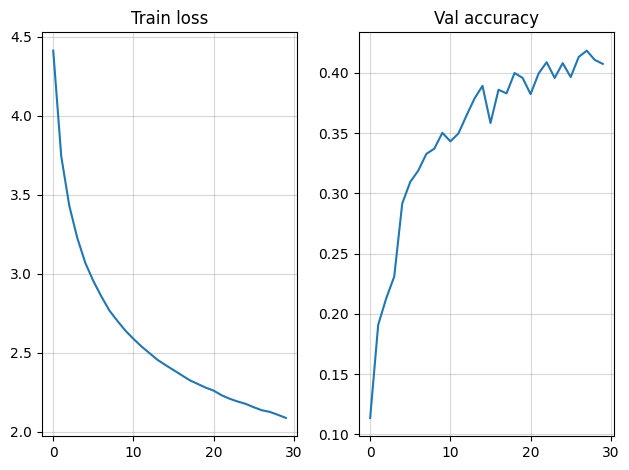

In [18]:
train_loop(model, opt, train_batch_gen, val_batch_gen, num_epochs=30)

**НАПИШИТЕ ВЫВОДЫ ПО ИТОГАМ ОБУЧЕНИЯ**

В целом, по графикам заметна положительная динамика в точности модели.

Вывод я пишу, пока у меня обучается ResNet, поэтому вывод о ResNet напишу позже. А пока только по VGG.

Сначала я подумал, что 40% - это немного. Но если учесть, что у нас 200 классов...

Если бы мы выбирали класс случайным образом - вероятность попасть была бы 1/200, т.е. 0.005 (== 0.5%)
Так что на фоне 0.5% точность в 40% очень даже ничего.

Обучение проходило гладенько, значит, (если я все правильно понимаю) lr выбирался оптимальным образом. Не зря оптимизатор использовали.

Сначала я обучал на CPU. После того, как за 40 минут прошло всего около 2 эпох до меня дошло, что есть GPU. На GPU все пошло куда быстрее - сетка обучилась за 50 минут.

Интересно, сколько будет обучаться ResNet...

Судя по графику, качество модели еще можно улучшить, так как график не вышел на плато. Возможно, можно добавить полносвязные слои в конце, для более лучшей классификации. Или, например, попробовать еще 1 слой сверточный добавить (по идее, он не слишком увеличит объем модели, и проблемы с затуханием градиентов возникнуть не должно).
Хотя.. Вряд-ли получится увеличить точность на много, так как, судя, по графику, он по-тихоньку на плато уже начал выходить (хотя потенциал роста еще есть).

В целом, интересную вещь заметил: если я правильно понимаю, то архитектура сети (точнее увеличение количества ядер на каждом из последующих блоков) - выбрана не случайно. Ведь, по сути, чем глубже мы уходим в сеть, тем более сложные паттерны она распознает, а инвариантов сложных паттернов (по типу глаз, рот, нос, ...) гораздо больше, чем элементарных (черта, ромб, квадрат, ...) (из которых состоят более сложные).

# Часть 2: ResNet

При увеличении глубины сети возникает проблема затухающих градиентов — обучение замедляется или останавливается. ResNet (He et al., 2015) решает это через остаточные соединения (**skip connections**):  
$y=F(x)+x$, где $F(x)$ — основная свертка, $x$ — "прямой путь". Это позволяет градиенту течь напрямую через сеть.

[Про резнет](https://disk.yandex.ru/i/7hVA5DS9aTBm2g) в оригинальной статье. Тут же написано про разные конфигурации, посмотрите.

На практике часто используются блоки с тремя свертками, поскольку они позволяют построить более глубокую сеть с меньшими параметрами. Блоки с двумя свертками обычно используются для сравнения с безостаточными сетями, особенно с VGG и AlexNet.

Как и в случае с VGG, мы собираемся создать нашу собственную конфигурацию для сети. Давайте используем **2 сверточных блока** для сравнения с vgg и возьмем сеть типа
> [Conv7x7 - 32] + [conv32-block, conv32-block] + [conv64-block, conv64-block] + [conv128-block, conv128-block] + [GlobalAveragePooling] + fc200 + softmax

По сравнению с ResNet18, мы уменьшили количество фильтров и убрали max-pooling в начале и в последнем наборе сверток, чтобы сохранить значимое пространственное разрешение.

In [19]:
class ResNetBlock2(nn.Module):
    """
    Module implements the following function:

    output = relu(F(input) + Residual(input)), where:
        Residual(x) = Conv + bn + relu + conv + bn
        F(x) = x                                        , if in_channels == out_channels and stride == 1
             = Conv1x1(in_channel, out_channel, stride) , otherwise
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        # TODO: определите conv1, bn1, relu1, conv2, bn2 для ветки подсчета остатков
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, 1, padding)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU()

        self.conv3 = None  # conv для главной ветки
        if in_channels != out_channels or stride != 1:
            self.conv3 = nn.Conv2d(in_channels, out_channels, 1, stride, padding=0)

    def forward(self, x):
        # TODO: вычислите ветку подсчета остатков,
        # НЕ ПЕРЕЗАПИСЫВАЙТЕ 'x' так как он нам нужен

        result1 = self.relu1(self.bn1(self.conv1(x)))
        residual = self.relu2(self.bn2(self.conv2(result1)))

        if self.conv3 is not None:
            x = self.conv3(x)

        result = self.relu2(residual + x)
        return result

def create_resnet_like_network():
    model = nn.Sequential()

    config = [[32, 32], [64, 64], [128, 128]]
    model.add_module('init_conv', ConvBNRelu(3, 32, kernel_size=7, stride=2, padding=3))

    in_channels = 32
    kernel_size = (3, 3)
    for i in range(len(config)):
        for j in range(len(config[i])):
            out_channels = config[i][j]
            stride = 2 if i != 0 and j == 0 else 1
            # TODO: добавьте ResNetBlock2 модуль в модель
            model.add_module(f'ResNet_{i}{j}_{in_channels}/{out_channels}', ResNetBlock2(in_channels, out_channels, kernel_size, stride))

            in_channels = out_channels
    model.add_module('pool', GlobalAveragePool((2,3)))
    model.add_module('logits', nn.Linear(out_channels, 200))
    return model

Тогда давайте потренируем нашу сеть. Обычно после обучения в течение 30 эпох вы должны получить нейронную сеть, которая предсказывает метки с точностью >40% и дает около +1% прибыли сети, подобной vgg, из предыдущего эксперимента.

In [20]:
# TODO: создайте resnet модель, перенесите ее на 'device', создайте такой же optimizer как и в прошлом эксперименте
model_resnet = create_resnet_like_network()
model_resnet.to(device)
print(model_resnet)

Sequential(
  (init_conv): ConvBNRelu(
    (conv): Conv2d(3, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (ResNet_00_32/32): ResNetBlock2(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU()
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU()
  )
  (ResNet_01_32/32): ResNetBlock2(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU()
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0

In [21]:
opt = torch.optim.Adam(model_resnet.parameters())

Epoch 30 of 30 took 104.626s
  training loss (in-iteration): 	1.746511
  validation accuracy: 			43.93 %


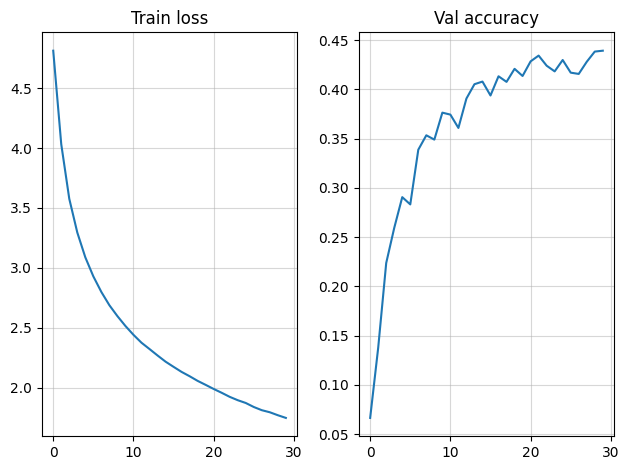

In [22]:
train_loop(model_resnet, opt, train_batch_gen, val_batch_gen, num_epochs=30)

**НАПИШИТЕ ВЫВОДЫ ПО ИТОГАМ ОБУЧЕНИЯ**

RezNet учится лучше (точность растет быстрее), чем VGG. Наверное, так и должно быть, ведь мы в каждом из блоков добавили по еще одному сверточному слою.
По времени, чуть по медленне, но не сильно.

Тут в целом тоже все достаточно гладенько.
По графику видно, что потенциала у RezNet больше, чем у VGG.

На сколько я понял, благодаря более глубокой архитектуре, RezNet может замечать более сложные паттерны, чем VGG.
А благодаря остаточным соединениям она быстрее обучается. (Несмотря на то, что она обучалась дольше VGG, она сама по себе почти в 2 раза больше. А обучалась не сильно то и дольше. Значит, по сравнению с VGG - ResNet обучается быстрее.)

На 15-й эпохе точность модели уже была 40%. (Это примерно на 7 эпох меньше, чем у VGG (считал постфактум, так что расчеты примерные))

И сам результат тоже лучше: 43% вместо 40%.

В целом, тут у модельки тоже есть потенциал к росту, но не уверен, что он высок. Судя по графикам, точность у RezNet уже начала выходить на плато. Итоговая точность, если увеличить количество эпох - скорее всего будет выше чем при аналогичных изменениях в VGG, но, не больше 60%, как мне кажется. (А может быть и 55%). Ведь если перегнуть с количеством эпох, то у модельки (хоть она и устойчивей к переобучению из-за остаточных соединений, но не на столько) будет переобучение.

А вот с увеличением количества полносвязных слоев не совсем понимаю, что будет. Точнее, точность увеличится, но на сколько не понимаю...

Если вы внимательно изучали нашу сеть resnet, то могли заметить, что она имеет почти в 2 раза больше параметров и в 2 раза глубже, чем сеть, подобная vgg. Давайте определим сопоставимую сеть, подобную vgg, удвоив количество уровней conv.

> [Conv(16), Conv(16), MaxPool] + [Conv(32), Conv(32), Conv(32), Conv(32), MaxPool] + [Conv(64), Conv(64), Conv(64), Conv(64), MaxPool] + [Conv(128), Conv(128), Conv(128), Conv(128)] + [GlobalAveragePooling] + [FC(200) + softmax]

Epoch 30 of 30 took 103.074s
  training loss (in-iteration): 	1.952305
  validation accuracy: 			39.91 %


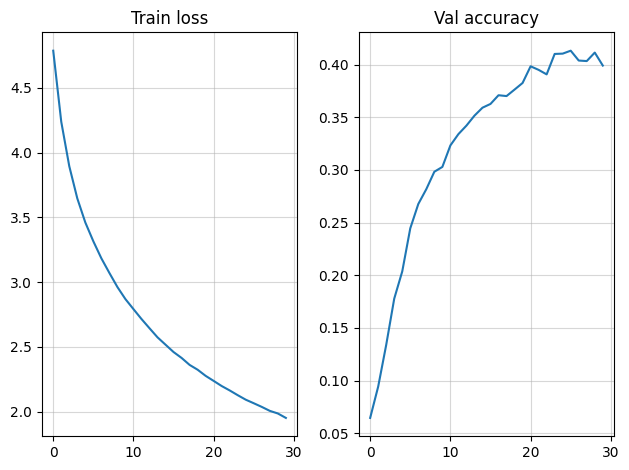

In [23]:
model = create_vgg_like_network(config=[[16,16], [32,32,32,32], [64, 64, 64, 64], [128, 128, 128, 128]])
model = model.to(device)
opt = torch.optim.Adam(model.parameters())
train_loop(model, opt, train_batch_gen, val_batch_gen, num_epochs=30)

**НАПИШИТЕ ИТОГОВЫЕ ВЫВОДЫ ПО ИТОГАМ ОБУЧЕНИЯ И СРАВНИТЕ ДВЕ АРХИТЕКТУРЫ**

В целом, RezNet сильно выигрывает по сравнению с VGG.
И по точности, и по скорости обучения (эпох в минуту) и по качеству обучения (как быстро растет точность с каждой эпохой)

Если я все правильно понял - это связано с остаточными соединениями.

Итого:

VGG
- Количество слоев (сверточных): 16 + 16 + 32 + 32 + 64 + 64 + 128 + 128 = 480
- Время обучения (30 эпох): 50 минут
- Скорость обучения (точность в эпоху) - ниже, чем у ResNet (я не замерял, поэтому не могу точно сказать, эх)
- Итоговая точность: 41%

ResNet:
- Количество слоев (сверточных): 32 + 32\*2 + 32\*2 + 64\*2 + 64\*2 + 128\*2 + 128\*2 = 928
- Время обучения (30 эпох): 51 минута
- Скорость обучения (точность в эпоху) - выше, чем у VGG (я не замерял, поэтому не могу точно сказать, эх)
- Итоговая точность: 43%


"Mega"VGG (Я понимаю, что это VGG, просто так удобнее различать)
- Количество слоев (сверточных): 16\*2 + 32\*4 + 64\*4 + 128\*4 = 928
- Время обучения (30 эпох):
- Скорость обучения (точность в эпоху) - ниже, чем у VGG
- Итоговая точность:
Интересно, что у "Mega"VGG кривая точности более гладкая, по сравнению с VGG и ResNet

Вообще, может быть MegaVGG и показало бы хорошую точность (около 40%), но для этого нужно больше, чем 30 эпох.
В целом, у MegaVGG потенциал точности (при увеличении количестве эпох) выше, чем у VGG, чисто из-за бОльшего количества параметров.


Но ResNet при таком же (примерно) количестве слоев обучается гораздо эффективнее и быстрее.


Итог на 30 эпохах:
- Победил ResNet!
- Второе место у VGG
- Третье у MegaVGG


Возможно (как мне кажется), на бОльшем количестве эпох:
- Победит ResNet
- Второе место MegaVGG
- Третье у VGG (и то он уже может переобучиться, как мне кажется)


В любом случае, у MegaVGG риск затухания градиентов больше. Конечно, это еще не deeeeeeeeep сеть, но с точки зрения теории вероятности, лучше такую "длинную" архитектуру для VGG не делать. (Зачем, если для этого есть RezNet.)